# Menghubungkan ke google drive dan memanggil dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd

folder_path = '/content/drive/MyDrive/Colab Notebooks/tokopedia_product_reviews_2025.csv'

try:
  df = pd.read_csv(folder_path)
  print("Data berhasil dimuat!")
  print(df.head()) # Menampilkan 5 baris pertama data
except FileNotFoundError:
  print(f"File tidak ditemukan di path: {folder_path}")
except Exception as e:
  print(f"Terjadi kesalahan: {e}")

Data berhasil dimuat!
                                         review_text review_date   review_id  \
0  baru sekali ini terima brg dr belanja online d...  2024-12-22  1134256160   
1  cocok bgt aku sama telur nya. nga Amis menurut...  2025-02-25  1242584634   
2  Telornya sudah sampai di rumah dengan kemasan ...  2025-07-15  1573444677   
3  Telor sudah diterima dengan baik dan tidak ada...  2025-07-20  1581728541   
4  Alhamdulillah penjual amanah,Telor nya terbaik...  2023-04-24   881041355   

                                        product_name   product_category  \
0  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
1  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
2  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
3  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
4  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   

   product_variant  product_price  \
0        

# Install Library di Colab

In [40]:
#install library
!pip install pandas nltk spacy matplotlib -q
!pip install spacy-stanza -q

#donwload resource
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

#donwload stanza bahasa indonesia
import stanza
stanza.download('id')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...
INFO:stanza:File exists: /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources


[['zip', 'default.zip']]

# Ambil Kolom Review (sesuaikan dengan nama kolom yang ada diproses)

In [45]:
print(df.columns)

Index(['review_text', 'review_date', 'review_id', 'product_name',
       'product_category', 'product_variant', 'product_price', 'product_url',
       'product_id', 'rating', 'sold_count', 'shop_id', 'sentiment_label'],
      dtype='object')


In [46]:
reviews = df['review_text'].dropna()

print(reviews.iloc[0])

baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli terlur ayam mentah , sec online. tp ternyata packing liar biasa. rapi, aman. Kerem seller


# Text Processing

In [44]:
# Stopword Bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# Kamus normalisasi slang / singkatan
slang_dict = {
    'gk': 'tidak',
    'ga': 'tidak',
    'gak': 'tidak',
    'nggak': 'tidak',
    'tdk': 'tidak',
    'bgt': 'banget',
    'bgtt': 'banget',
    'dgn': 'dengan',
    'dg' : 'dengan',
    'dr': 'dari',
    'brg': 'barang',
    'brgnya': 'barangnya',
    'yg': 'yang',
    'aja': 'saja',
    'udh': 'sudah',
    'sdh': 'sudah',
    'blm': 'belum',
    'sm': 'sama',
    'krn': 'karena',
    'tp': 'tapi',
    'trs': 'terus',
    'dapet': 'dapat',
    'dpt': 'dapat',
    'mantul': 'mantap',
    'okeee': 'oke',
    'baguuus': 'bagus',
    'cepet': 'cepat'
}

def normalize_slang(word):
    return slang_dict[word] if word in slang_dict else word

def remove_repeated_char(word):
    # baguuuus -> bagus
    return re.sub(r'(.)\1+', r'\1', word)

def clean_text(text):

    # lowercase
    text = str(text).lower()

    # hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus mention dan hashtag
    text = re.sub(r'@\w+|#\w+', '', text)

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus emoji dan simbol
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenisasi
    tokens = word_tokenize(text)

    clean_tokens = []

    for word in tokens:

        # hapus huruf berulang
        word = remove_repeated_char(word)

        # normalisasi slang
        word = normalize_slang(word)

        # hapus stopword
        if word not in stop_words and len(word) > 1:
            clean_tokens.append(word)

    return clean_tokens

# preprocessing review_text
tokens = df['review_text'].dropna().apply(clean_text)

# tampilkan hasil
print(tokens.iloc[0])

['terima', 'barang', 'belanja', 'online', 'packing', 'super', 'rapih', 'aman', 'ragu', 'mbeli', 'terlur', 'ayam', 'mentah', 'sec', 'online', 'packing', 'liar', 'rapi', 'aman', 'kerem', 'seler']


# Implementasi N-Gram

A. Unigram



In [12]:
# mengimpor Counter dari library collections
# counter digunakan untuk menghitung frekuensi kemunculan kata
from collections import Counter

all_words = []

for sentence in tokens:
    all_words.extend(sentence)

# menghitung jumlah kemunculan setiap kata
unigram = Counter(all_words)

# menampilkan 10 kata yang paling sering muncul
print(unigram.most_common(10))

[('dan', 22656), ('sesuai', 16103), ('cepat', 16032), ('barang', 15515), ('bagus', 13992), ('pengiriman', 11276), ('seller', 8746), ('di', 8455), ('dengan', 8451), ('baik', 8050)]


B. Bigram

In [13]:
# mengimpor fungsi bigrams dari nltk.util
# bigram digunakan untuk membuat pasangan 2 kata berurutan
from nltk.util import bigrams

bigram_list = []

for sentence in tokens:
    bigram_list.extend(list(bigrams(sentence)))

# menghitung frekuensi kemunculan setiap bigram
bigram_freq = Counter(bigram_list)

# menampilkan 10 bigram yang paling sering muncul
print(bigram_freq.most_common(10))

[(('pengiriman', 'cepat'), 6220), (('terima', 'kasih'), 4193), (('barang', 'sesuai'), 4072), (('sesuai', 'deskripsi'), 3589), (('sesuai', 'pesanan'), 3229), (('dengan', 'baik'), 2562), (('sesuai', 'dengan'), 2019), (('packing', 'aman'), 1953), (('barang', 'bagus'), 1910), (('cepat', 'dan'), 1574)]


C. Trigram

In [14]:
# mengimpor fungsi trigrams dari nltk.util
# trigram digunakan untuk membuat kelompok 3 kata berurutan
from nltk.util import trigrams

trigram_list = []

for sentence in tokens:
    trigram_list.extend(list(trigrams(sentence)))

# menghitung frekuensi kemunculan setiap trigram
trigram_freq = Counter(trigram_list)

# menampilkan 10 trigram yang paling sering muncul
print(trigram_freq.most_common(10))

[(('barang', 'sesuai', 'deskripsi'), 1252), (('is', 'the', 'best'), 1159), (('berfungsi', 'dengan', 'baik'), 1137), (('mantap', 'is', 'the'), 1135), (('top', 'mantap', 'is'), 1134), (('the', 'best', 'top'), 1132), (('best', 'top', 'mantap'), 1132), (('barang', 'sesuai', 'pesanan'), 876), (('dan', 'pengiriman', 'cepat'), 796), (('diterima', 'dengan', 'baik'), 696)]


Visualisasi N-Gram

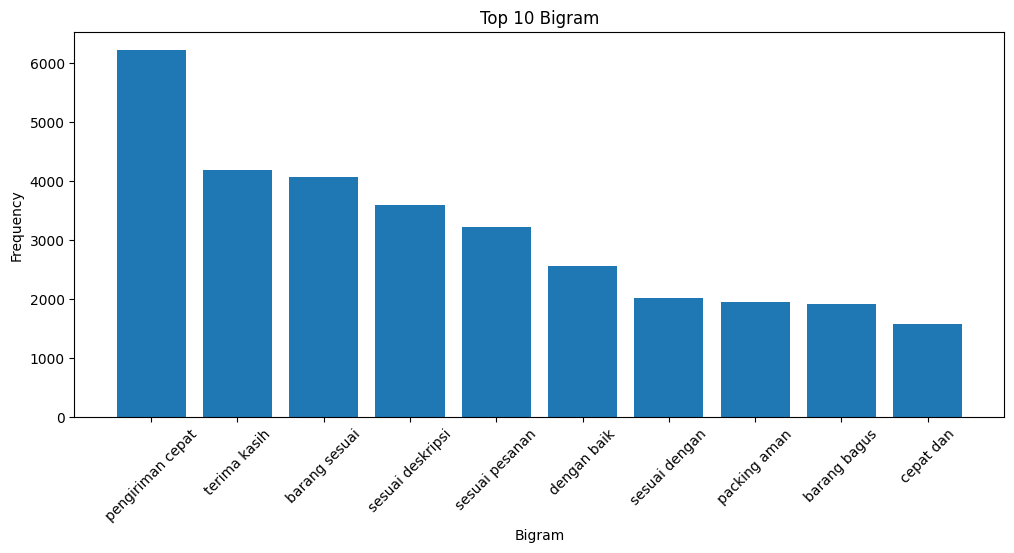

In [15]:
import matplotlib.pyplot as plt

# mengambil 10 bigram dengan frekuensi tertinggi
top_bigram = bigram_freq.most_common(10)

labels = [' '.join(bg) for bg, freq in top_bigram]
values = [freq for bg, freq in top_bigram]

# membuat grafik batang (bar chart)
# labels = nama bigram
# values = jumlah frekuensi
plt.figure(figsize=(12,5))
plt.bar(labels, values)

plt.xticks(rotation=45) # memiringkan teks pada sumbu X agar lebih mudah dibaca
plt.title("Top 10 Bigram") #judul grafik
plt.xlabel("Bigram") #nama sumbu x
plt.ylabel("Frequency") #nama sumbu y

# menampilkan grafik
plt.show()

Probabilitas N-Gram


In [16]:
#implementasi rumus
word_count = Counter(all_words)

for bg, count in list(bigram_freq.items())[:10]:
    prob = count / word_count[bg[0]]

    print(f"{bg} -> {prob:.4f}")

('baru', 'sekali') -> 0.0095
('sekali', 'ini') -> 0.0037
('ini', 'terima') -> 0.0061
('terima', 'brg') -> 0.0002
('brg', 'dr') -> 0.0020
('dr', 'belanja') -> 0.0021
('belanja', 'online') -> 0.0173
('online', 'dg') -> 0.0056
('dg', 'packing') -> 0.0085
('packing', 'super') -> 0.0183


# Implementasi Parsing

In [21]:
reviews_50 = reviews_clean.sample(50, random_state=42)

print(reviews_50.iloc[0])

kemasannya exclusive bgttt pengiriman cepat sampai dgn selamat kurmanya lumayan besar dibanding yg biasanya sy liat teksturnya juga ngga terlalu kering jadi enak ngga keras pas dimakan love bgt sm castle farms


1. **Constituency Parsing**

In [22]:
stanza.download('id')

nlp_const = stanza.Pipeline(
    lang='id',
    processors='tokenize,pos,constituency'
)

constituency_results = []

for sentence in reviews_50:

    try:
        doc = nlp_const(sentence)

        for sent in doc.sentences:
            constituency_results.append(str(sent.constituency))

    except:
        constituency_results.append("Parsing Error")

INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...
INFO:stanza:File exists: /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor    | Package     |
------------------------------
| tokenize     | gsd         |
| mwt          | gsd         |
| pos          | gsd_charlm  |
| constituency | icon_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: constituency
INFO:stanza:Done loading processors!


Hasil dengan visualisasi tree

In [28]:
for i in range(5):

    text = reviews_50.iloc[i]

    print(f"\nKalimat {i+1}:")
    print(text)

    doc = nlp_const(text)

    tree_text = str(doc.sentences[0].constituency)

    tree = Tree.fromstring(tree_text)

    tree.pretty_print()


Kalimat 1:
kemasannya exclusive bgttt pengiriman cepat sampai dgn selamat kurmanya lumayan besar dibanding yg biasanya sy liat teksturnya juga ngga terlalu kering jadi enak ngga keras pas dimakan love bgt sm castle farms
                                                     ROOT                                                                                                                                                                                             
                                                      |                                                                                                                                                                                                
                                                      S                                                                                                                                                                                               
          __________________________

2. **Dependency Parsing**

In [24]:
nlp_dep = stanza.Pipeline(
    lang='id',
    processors='tokenize,pos,lemma,depparse'
)
dependency_results = []
for sentence in reviews_50:
    try:
        doc = nlp_dep(sentence)

        sentence_result = []

        for sent in doc.sentences:

            for word in sent.words:

                sentence_result.append({
                    'word': word.text,
                    'head': word.head,
                    'relation': word.deprel
                })
        dependency_results.append(sentence_result)

    except:
        dependency_results.append("Parsing Error")

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |
| depparse  | gsd_charlm   |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!


Hasil dengan visualisasi graph

In [39]:
import spacy_stanza
from spacy import displacy
# Pipeline Bahasa Indonesia
snlp = spacy_stanza.load_pipeline(
    "id",
    processors="tokenize,pos,lemma,depparse"
)
# Ambil 50 review dari review_text
reviews_50 = reviews_clean.sample(50, random_state=42)
# Dependency Parsing untuk 5 kalimat
for i in range(5):
    sentence = reviews_50.iloc[i]
    print("="*100)
    print(f"Kalimat {i+1}")
    print(sentence)
    try:
        # Parsing
        doc = snlp(sentence)
        # Visualisasi dependency graph
        displacy.render(
            doc,
            style="dep",
            jupyter=True,
            options={'distance': 120}
        )
    except Exception as e:
        print("Error:", e)

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor | Package      |
----------------------------
| tokenize  | gsd          |
| mwt       | gsd          |
| pos       | gsd_charlm   |
| lemma     | gsd_nocharlm |
| depparse  | gsd_charlm   |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!


Kalimat 1
kemasannya exclusive bgttt pengiriman cepat sampai dgn selamat kurmanya lumayan besar dibanding yg biasanya sy liat teksturnya juga ngga terlalu kering jadi enak ngga keras pas dimakan love bgt sm castle farms


Kalimat 2
kipas kecil tp cabe rawit keren bnget krn rata tasku mini smua tp msih muat kok dapat hrga murcee rban moga awet yah


Kalimat 3
baguslangsung pakai mantabbb


Kalimat 4
sayur amp lauk semua fresh respon cepat dan baik pengiriman juga cepat mantul


Kalimat 5
good
